In [1]:
from pathlib import Path
import sys
import random
import pickle
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
sys.path.append(str(Path.cwd().parents[1] / "code"))
from utils import *

## Experiment setup

In [2]:
# Generate the underlying physical graph.
N_nodes = 50
G = nx.erdos_renyi_graph(N_nodes, p=0.1)

while not nx.is_connected(G):
    G = nx.erdos_renyi_graph(N_nodes, p=0.1)

# Experiment parameters.
seq_len = 10^7
walkers = 10
sparsity = 0.2
max_order = 4
start_p = 1
max_p = 6
threshold = 0.02

## Run experiment

In [ ]:
# Generate contact data for different Markov orders.
list_data = []

for order in range(max_order):
    obj_list = generate_contact_data_from_graph(
        graph=G,
        n_walkers=walkers,
        markov_order=order,
        sequence_length=seq_len,
        sparsity=sparsity,
        #return_final_state_ids = True
    )
    list_data.append(obj_list)


# Compute the order-inference metric.
max_length = min(
    len(list_data[order]["contacts"])
    for order in range(max_order)
)

list_contact_data = []

for order in range(max_order):
    list_contact_data.append(list_data[order]["contacts"][:max_length])


all_metrics = []
for contacts in tqdm(list_contact_data):
    avg_ratio = average_metric(contacts, start_p=start_p, max_p=max_p)
    all_metrics.append(avg_ratio)

## Alternative: load precomputed results

In [3]:
all_metrics = open_graph("order_inference_metrics")

## Visualization

In [4]:
sns.set_theme(style="ticks", context="paper", palette="colorblind")

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 20,
    "axes.titlesize": 30,
    "axes.labelsize": 20,
    "legend.fontsize": 22,
    "legend.title_fontsize": 25,
    "xtick.labelsize": 25,
    "ytick.labelsize": 25,
    "lines.linewidth": 3,
    "axes.linewidth": 0.8
})


# Plot the order-inference metric.
def plot_metric(all_metrics, labels, start_p=1, threshold=0.01):
    fig, ax = plt.subplots(figsize=(11, 8))
    num_sequences = len(all_metrics)
    palette = sns.color_palette("muted", num_sequences)
    orders = list(range(start_p, start_p + len(all_metrics[0])))

    ax.set_xlabel("History length, $h$", fontsize=30, labelpad=30)
    ax.set_ylabel("Incremental contribution", fontsize=30, labelpad=35)

    ax.set_xticks([])
    ax.set_yticks([])
    x_max = max(orders) * 1.05
    y_max = max(1, max(max(values) for values in all_metrics))

    ax.set_xlim(start_p - 0.03 * x_max, 1.02 * x_max)
    ax.set_ylim(-0.03 * y_max, 1.1 * y_max)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.annotate(
        "",
        xy=(x_max, 0),
        xytext=(start_p, 0),
        arrowprops=dict(arrowstyle="-|>", color="black", lw=5, mutation_scale=20)
    )

    ax.annotate(
        "",
        xy=(start_p, y_max * 1.1),
        xytext=(start_p, 0),
        arrowprops=dict(arrowstyle="-|>", color="black", lw=5, mutation_scale=20)
    )

    y_ticks = np.linspace(0, y_max, 6)
    y_tick_length = 0.015 * (x_max - start_p)

    for y in y_ticks:
        ax.plot(
            [start_p - y_tick_length, start_p],
            [y, y],
            color="black",
            linewidth=1.5,
            zorder=2
        )

        ax.text(
            start_p - 2.0 * y_tick_length,
            y,
            f"{y:g}",
            ha="right",
            va="center",
            fontsize=25
        )

    x_tick_length = 0.015 * y_max

    for x in orders:
        ax.plot(
            [x, x],
            [0, -x_tick_length * 2.2],
            color="black",
            linewidth=1.5,
            zorder=2
        )

        ax.text(
            x,
            -2.8 * x_tick_length,
            f"{x:.3g}",
            ha="center",
            va="top",
            fontsize=25
        )

    for i, (values, label) in enumerate(zip(all_metrics, labels)):
        order_est = estimate_order(values, threshold=threshold)
        ax.plot(
            orders,
            values,
            label=rf"${label} \rightarrow \hat{{p}}={order_est}$",
            color=palette[i],
            marker="o",
            linewidth=7,
            markersize=18,
            zorder=3
        )

    ax.legend(
        title=r"Markov order, p:",
        frameon=True,
        bbox_to_anchor=(1.005, 1.01),
    )

    plt.tight_layout()
    plt.savefig(
        "true_estimated_order.png",
        bbox_inches="tight",
        dpi=300,
    )
    plt.show()

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

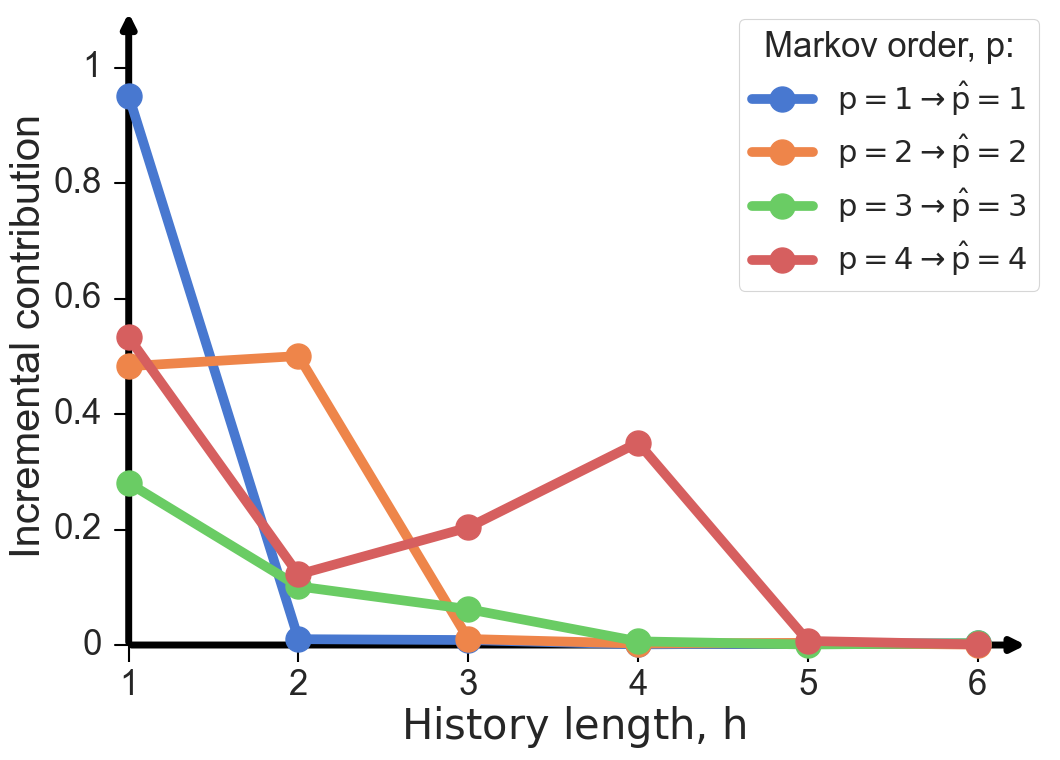

In [5]:
labels = []
for i in range(max_order):
    labels.append(f"p = {i+1}")

plot_metric(all_metrics, labels, start_p=start_p, threshold=threshold)